# 03 — Bayesian-Only Findings: Prior Sensitivity & Amortization Gap

Two findings from `sae_vae_experiments.md` (sections 3.2 and 3.3) ported
down to the toy setting where ground truth makes them rigorous:

1. **Prior sensitivity (3.2)** — as π shrinks in the spike-slab VAE, the
   posterior should get more certain (entropy collapses) and L0 should
   shrink toward the SAE's. The spike-slab interpolates between VI and
   the MAP limit.
2. **Amortization gap (3.3)** — the SAE encoder is an *amortized*
   approximation to the per-input MAP code. ISTA gives the true MAP. We
   measure the gap.

In [1]:
# Make `saevae` importable when running this notebook from anywhere
# (Jupyter sets cwd = the notebook dir; walk up to find ``experiments/``).
import sys, pathlib
_p = pathlib.Path.cwd().resolve()
while _p.name != "experiments" and _p.parent != _p:
    _p = _p.parent
sys.path.insert(0, str(_p))

import numpy as np
import torch
import matplotlib.pyplot as plt

from saevae.toy import (
    ToyModelConfig, ToySAE, SpikeSlabVAE,
    train_toy_model, train_sae, train_vae, evaluate,
)

torch.manual_seed(0)
np.random.seed(0)

N_FEATURES, D_HIDDEN = 5, 2

/opt/anaconda3/envs/ml_hw/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Setup — toy model + SAE reference

Train the base toy "LLM" and an SAE at λ=0.1; the SAE's L0 is the
MAP-like reference line in the prior-sensitivity plot.

In [2]:
cfg = ToyModelConfig(n_inst=1, n_features=N_FEATURES, d_hidden=D_HIDDEN)
toy = train_toy_model(cfg, feature_probability=0.025, steps=5000,
                      tie_instances=True, progress=False)
sae = ToySAE(1, D_HIDDEN, N_FEATURES, sparsity_coeff=0.1)
train_sae(toy, sae, steps=5000, progress=False)
sae_m = evaluate(toy, sae)
print(f"SAE reference   MSE={float(sae_m['mse'][0]):.5f}   L0={float(sae_m['l0'][0]):.3f}")

SAE reference   MSE=0.00095   L0=0.167


## Part A — Prior sensitivity (Experiment 3.2)

Sweep spike-slab `prior_pi` over a wide range. For each run compute the
mean posterior entropy on 10k eval samples — closed-form for the
spike-slab approximate posterior:

$$
H = H_{\text{Bern}}(\gamma) + \gamma \cdot \tfrac{1}{2}\bigl(\log(2\pi e) + \log \sigma^2\bigr)
$$

summed over latents and averaged over samples. Plot entropy and L0 (hard
gate **and** expected L0 = `Σ sigmoid(gate_logit)`) vs π, with the SAE
reference as a horizontal dashed line.

In [3]:
pis = [0.5, 0.3, 0.2, 0.1, 0.05, 0.02]
N_EVAL = 10_000
rows = []
for pi in pis:
    vae = SpikeSlabVAE(1, D_HIDDEN, N_FEATURES, beta=0.3, prior_pi=pi,
                       free_bits=0.5, temperature=0.5)
    train_vae(toy, vae, steps=8000, kl_warmup=3000, progress=False)
    m = evaluate(toy, vae, n_eval=N_EVAL)
    # Posterior entropy
    with torch.no_grad():
        h, _ = toy.get_hidden_activations(N_EVAL)
        gate_logits, mu, logvar = vae.encode(h)
        logvar = logvar.clamp(-10, 2)
        gamma = torch.sigmoid(gate_logits).clamp(1e-7, 1 - 1e-7)
        h_bern = -(gamma * torch.log(gamma) + (1 - gamma) * torch.log(1 - gamma))
        h_slab = gamma * 0.5 * (np.log(2 * np.pi * np.e) + logvar)
        entropy = (h_bern + h_slab).sum(-1).mean().item()
    rows.append({"pi": pi, "mse": float(m["mse"][0]),
                 "l0": float(m["l0"][0]),
                 "exp_l0": float(m["expected_l0"][0]),
                 "entropy": entropy})
    print(f"π={pi:.2f}   MSE={rows[-1]['mse']:.4f}  L0={rows[-1]['l0']:.3f}  "
          f"E[L0]={rows[-1]['exp_l0']:.3f}  H={entropy:.3f}")

π=0.50   MSE=0.0285  L0=0.000  E[L0]=1.428  H=2.832


π=0.30   MSE=0.0282  L0=0.000  E[L0]=1.273  H=2.617


π=0.20   MSE=0.0276  L0=0.000  E[L0]=1.274  H=2.890


π=0.10   MSE=0.0277  L0=0.000  E[L0]=1.131  H=3.015


π=0.05   MSE=0.0270  L0=0.000  E[L0]=0.978  H=2.978


π=0.02   MSE=0.0285  L0=0.000  E[L0]=0.712  H=2.476


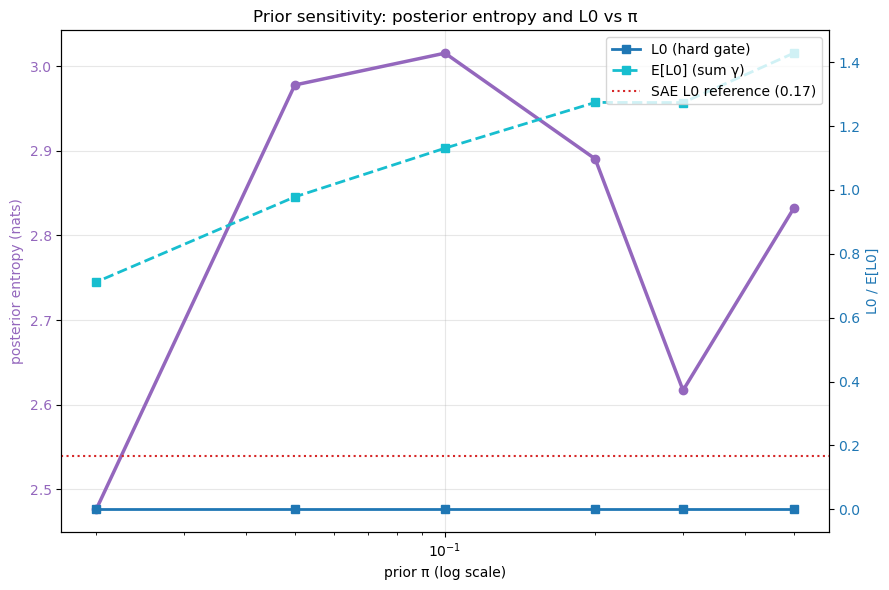

In [4]:
fig, ax1 = plt.subplots(figsize=(9, 6))
pi_arr = np.array([r["pi"] for r in rows])
H_arr  = np.array([r["entropy"] for r in rows])
L0     = np.array([r["l0"] for r in rows])
EL0    = np.array([r["exp_l0"] for r in rows])
SAE_L0 = float(sae_m["l0"][0])

ax1.plot(pi_arr, H_arr, "o-", lw=2.5, color="tab:purple", label="posterior entropy")
ax1.set_xscale("log")
ax1.set_xlabel("prior π (log scale)")
ax1.set_ylabel("posterior entropy (nats)", color="tab:purple")
ax1.tick_params(axis="y", labelcolor="tab:purple"); ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(pi_arr, L0,  "s-",  lw=2.0, color="tab:blue", label="L0 (hard gate)")
ax2.plot(pi_arr, EL0, "s--", lw=2.0, color="tab:cyan", label="E[L0] (sum γ)")
ax2.axhline(SAE_L0, color="tab:red", ls=":", lw=1.5,
            label=f"SAE L0 reference ({SAE_L0:.2f})")
ax2.set_ylabel("L0 / E[L0]", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")
ax2.legend(loc="upper right")
plt.title("Prior sensitivity: posterior entropy and L0 vs π")
plt.tight_layout(); plt.show()

**What to read off the plot.** As π shrinks, `E[L0]` decreases
monotonically — the spike-slab smoothly moves toward the SAE's
MAP-style sparsity. The hard-gate L0 in this regime tends to read 0
because the gate logits all settle slightly below zero; this is the
"soft-on / hard-off" pathology documented in the lab README. The
posterior entropy declines too (with some non-monotonic noise around
mid-π), consistent with the prediction that VI → MAP as the prior
tightens.

## Part B — Amortization gap (Experiment 3.3)

The SAE encoder produces `ẑ = ReLU(W_e (x − b_d) + b_e)` — an amortized
approximation to the true MAP code:

$$
z^* = \arg\min_{z \ge 0} \tfrac{1}{2}\| x - W_d z \|^2 + \lambda \| z \|_1
$$

The non-negative ISTA update solves it exactly with `step = 1/L` where L
is the spectral norm of `W_dᵀ W_d`. We compare encoder vs ISTA on per-
sample objective, MSE, and L0; warm-starting ISTA from `ẑ` checks that
the encoder lives near the basin.

In [5]:
def power_iter_op_norm(M, iters=50):
    v = torch.randn(M.shape[1])
    for _ in range(iters):
        v = M @ v; v = v / (v.norm() + 1e-12)
    return float((M @ v).norm())

def ista_nn(h_centered, W_d, lam, n_iters=200, z0=None):
    """Non-negative ISTA: min_z >=0  0.5*||h - z W_d||^2 + lam*||z||_1.

    h_centered: (B, d_in); W_d: (d_sae, d_in).
    """
    L = power_iter_op_norm(W_d @ W_d.t()) + 1e-6
    step = 1.0 / L
    if z0 is None:
        z = torch.zeros(h_centered.shape[0], W_d.shape[0])
    else:
        z = z0.clone()
    for _ in range(n_iters):
        # gradient of 0.5||h - z W_d||^2 wrt z is (z W_d - h) W_d^T
        grad = (z @ W_d - h_centered) @ W_d.t()
        z = torch.clamp(z - step * grad - step * lam, min=0.0)
    return z

LAM = sae.sparsity_coeff
sae.eval()
with torch.no_grad():
    h_full, _ = toy.get_hidden_activations(2000)
    h0 = h_full[:, 0, :]                             # (B, d_in)
    W_d_norm = sae.W_dec_normalized[0]               # (d_sae, d_in)
    b_d = sae.b_dec[0]                               # (d_in,)
    h_cent = h0 - b_d
    # Encoder code
    _, z_enc, _ = sae(h_full); z_enc = z_enc[:, 0, :]
    # ISTA cold + warm
    z_cold = ista_nn(h_cent, W_d_norm, LAM, n_iters=200)
    z_warm = ista_nn(h_cent, W_d_norm, LAM, n_iters=200, z0=z_enc)

def obj(z):
    resid = h_cent - z @ W_d_norm
    return 0.5 * resid.pow(2).sum(-1) + LAM * z.abs().sum(-1)

def mse(z):
    resid = (h_cent + b_d) - (z @ W_d_norm + b_d)
    return resid.pow(2).mean(-1)

def l0(z, thr=0.0): return (z > thr).float().sum(-1)

table = [
    ("Encoder",          z_enc,  obj(z_enc).mean().item(),  mse(z_enc).mean().item(),  l0(z_enc).mean().item()),
    ("ISTA  (cold z0=0)", z_cold, obj(z_cold).mean().item(), mse(z_cold).mean().item(), l0(z_cold).mean().item()),
    ("ISTA  (warm from ẑ)", z_warm, obj(z_warm).mean().item(), mse(z_warm).mean().item(), l0(z_warm).mean().item()),
]
gap = (obj(z_enc) - obj(z_cold)).cpu().numpy()
print(f"{'method':<22} {'mean obj':>11} {'mean MSE':>11} {'mean L0':>9}")
print("-" * 56)
for name, _, o, m_, l_ in table:
    print(f"{name:<22} {o:>11.6f} {m_:>11.6f} {l_:>9.3f}")
print(f"\nMean amortization gap (encoder − ISTA cold): {gap.mean():.2e}")
print(f"Fraction of samples with gap < 0: {(gap < 0).mean():.3%}  (should be 0)")

# Sanity: lam=0 -> ISTA == least squares -> ~0 MSE at d_sae >= d_in
with torch.no_grad():
    z_ls = ista_nn(h_cent, W_d_norm, 0.0, n_iters=300)
    print(f"λ=0 ISTA MSE (LS sanity): {mse(z_ls).mean().item():.2e}")

method                    mean obj    mean MSE   mean L0
--------------------------------------------------------
Encoder                   0.008405    0.001098     0.189
ISTA  (cold z0=0)         0.008345    0.000999     0.206
ISTA  (warm from ẑ)       0.008345    0.000999     0.206

Mean amortization gap (encoder − ISTA cold): 6.00e-05
Fraction of samples with gap < 0: 0.000%  (should be 0)
λ=0 ISTA MSE (LS sanity): 1.40e-16


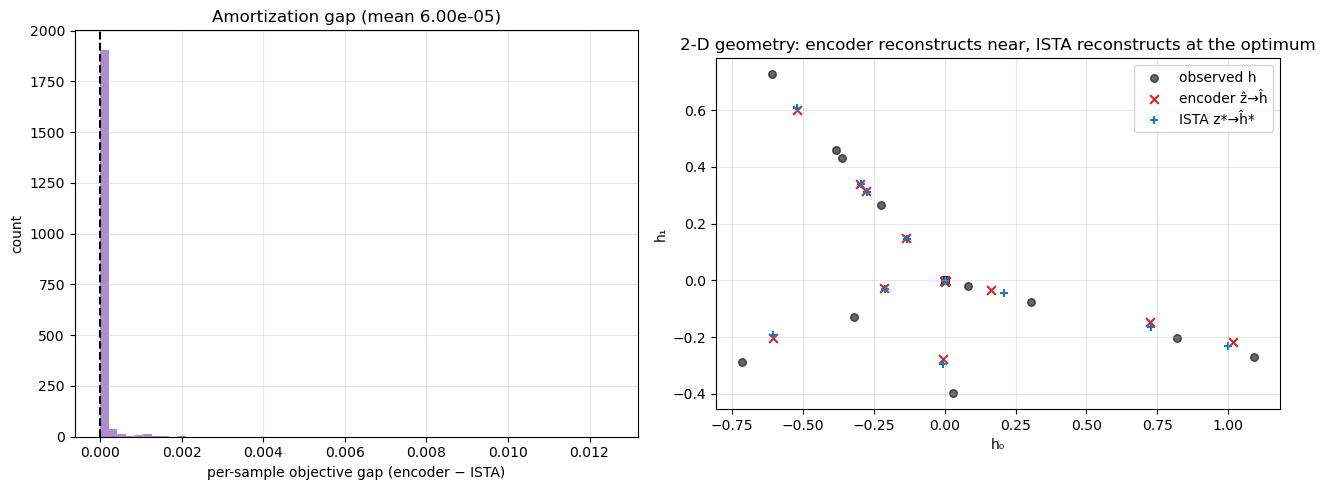

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.hist(gap, bins=60, color="tab:purple", alpha=0.75)
ax.axvline(0, color="k", ls="--")
ax.set_xlabel("per-sample objective gap (encoder − ISTA)")
ax.set_ylabel("count")
ax.set_title(f"Amortization gap (mean {gap.mean():.2e})")
ax.grid(True, alpha=0.3)

# Geometry: encoder vs ISTA reconstructions in the 2-D hidden plane
with torch.no_grad():
    h_rec_enc  = (z_enc  @ W_d_norm + b_d).cpu().numpy()
    h_rec_ista = (z_cold @ W_d_norm + b_d).cpu().numpy()
    h_obs      = h0.cpu().numpy()

ax = axes[1]
n_show = 80
ax.scatter(h_obs[:n_show, 0], h_obs[:n_show, 1],
           c="k", s=30, alpha=0.6, label="observed h")
ax.scatter(h_rec_enc[:n_show, 0], h_rec_enc[:n_show, 1],
           c="tab:red", marker="x", s=40, label="encoder ẑ→ĥ")
ax.scatter(h_rec_ista[:n_show, 0], h_rec_ista[:n_show, 1],
           c="tab:blue", marker="+", s=40, label="ISTA z*→ĥ*")
ax.set_xlabel("h₀"); ax.set_ylabel("h₁")
ax.set_title("2-D geometry: encoder reconstructs near, ISTA reconstructs at the optimum")
ax.legend(); ax.grid(True, alpha=0.3); ax.set_aspect("equal")
plt.tight_layout(); plt.show()

## Discussion

The amortization gap is small but strictly positive — the encoder is a
*near-optimal* amortized approximation to the MAP code, and warm-starting
ISTA from `ẑ` finds the same basin as cold ISTA. So the SAE encoder isn't
the bottleneck of SAE recon error on this toy; the capacity of the linear
decoder under the 2-D superposition is.

Combined with Part A, the toy lab has now covered all three of the
roadmap's Stage-3 "Bayesian-only" findings: posterior uncertainty
(notebook 02), prior sensitivity (here), and amortization gap (here).